In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '9'
jax.config.update('jax_enable_x64', True)

## Small lattice, visualizing dynamics of all states

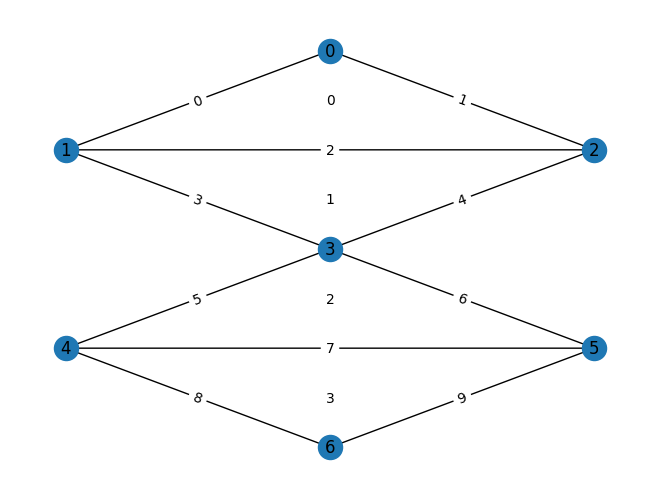

In [2]:
config = '''
 *
* *
 *
* *
 *
'''

lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [3]:
plaquette_energy = 1.
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][[0, 3, 6, 9]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

In [4]:
hamiltonian

SparsePauliOp(['IIIZ', 'IIIZ', 'IIZZ', 'IIZI', 'IIZI', 'IZII', 'IZII', 'ZZII', 'ZIII', 'ZIII', 'IIIX', 'IIXI', 'IXII', 'XIII'],
              coeffs=[ 1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j,
 -1.+0.j,  1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])

In [5]:
tpoints = np.linspace(0., 3.2, 161)
hvec = make_hvec(hamiltonian)
psi_full = integrate(hvec, nplaq, tpoints)


INFO:2025-12-13 00:03:26,236:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [6]:
probs_full = np.square(np.abs(psi_full))

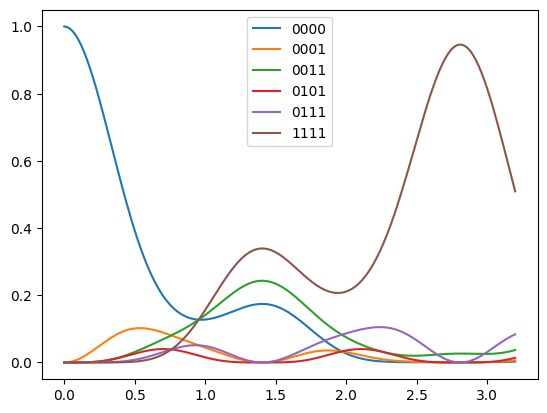

In [7]:
plt.plot(tpoints, probs_full[:, [0, 1, 3, 5, 7, 15]], label=[f'{i:04b}' for i in [0, 1, 3, 5, 7, 15]])
# plt.plot(tpoints, probs_full[:, [5, 9]], label=[f'{i:04b}' for i in [5, 6]])
# plt.plot(tpoints, probs_full, label=[f'{i:04b}' for i in range(16)])
plt.legend();

In [8]:
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())

In [9]:
eigvals

array([-4.47213595e+00, -3.23606798e+00, -3.23606798e+00, -2.00000000e+00,
       -1.23606798e+00, -1.23606798e+00, -1.63082351e-16,  2.51802531e-16,
        1.24909187e-15,  2.30662513e-15,  1.23606798e+00,  1.23606798e+00,
        2.00000000e+00,  3.23606798e+00,  3.23606798e+00,  4.47213595e+00])

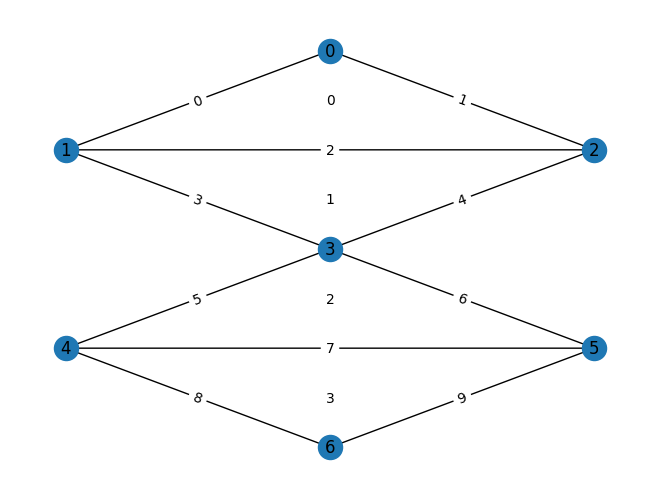

In [10]:
lattice.draw_graph();

In [11]:
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())

In [12]:
probs = np.square(np.abs(eigvecs[:, 0]))
sort_idx = np.argsort(probs)[::-1]
sorted_probs = probs[sort_idx]

In [13]:
for idx, prob in zip(sort_idx, sorted_probs):
    print(np.nonzero((idx >> np.arange(4)) % 2), prob)

(array([2, 3]),) 0.13090169943749477
(array([], dtype=int64),) 0.13090169943749477
(array([0, 1]),) 0.13090169943749472
(array([0, 1, 2, 3]),) 0.13090169943749458
(array([1]),) 0.05000000000000004
(array([2]),) 0.050000000000000024
(array([1, 2, 3]),) 0.050000000000000024
(array([3]),) 0.05000000000000001
(array([0, 1, 2]),) 0.05000000000000001
(array([0, 2, 3]),) 0.049999999999999996
(array([0, 1, 3]),) 0.049999999999999996
(array([0]),) 0.04999999999999996
(array([1, 2]),) 0.019098300562505246
(array([1, 3]),) 0.019098300562505246
(array([0, 3]),) 0.01909830056250524
(array([0, 2]),) 0.01909830056250524


In [14]:
delta_ts = np.linspace(0.1, 1.0, 10)
psi_1 = np.empty((delta_ts.shape[0], 2 ** nplaq), dtype=np.complex128)
psi_2 = np.empty((delta_ts.shape[0], 2 ** nplaq), dtype=np.complex128)
for idt, delta_t in enumerate(delta_ts):
    trotter_uvec = make_trotter_uvec(hamiltonian, delta_t)
    psis = simulate(trotter_uvec, nplaq, 2, num_substeps=1, dims=(1, 2))
    psi_1[idt] = psis[0]
    psi_2[idt] = psis[1]
probs_1 = np.square(np.abs(psi_1))
probs_2 = np.square(np.abs(psi_2))

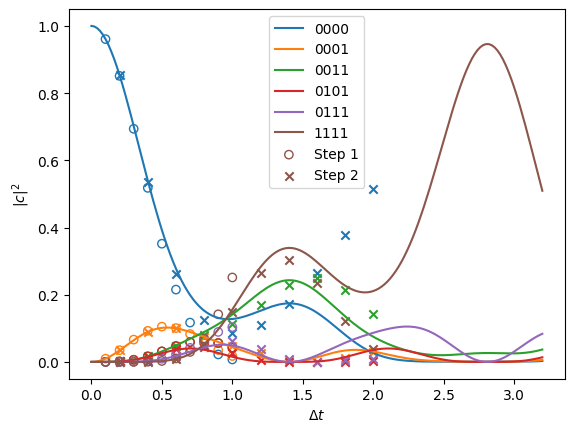

In [23]:
indices = [0, 1, 3, 5, 7, 15]
# indices = [3, 5]
lines = plt.plot(tpoints, probs_full[:, indices])
for idx, line in zip(indices, lines):
    pc1 = plt.scatter(delta_ts, probs_1[:, idx], facecolor='none', edgecolor=line.get_color())
    pc2 = plt.scatter(2. * delta_ts, probs_2[:, idx], marker='x', facecolor=line.get_color())
# plt.yscale('log')
plt.xlabel(r'$\Delta t$')
plt.ylabel(r'$|c|^2$')
plt.legend(lines + [pc1, pc2], [f'{i:04b}' for i in indices] + ['Step 1', 'Step 2'])

## Larger lattice, exact versus Trotter

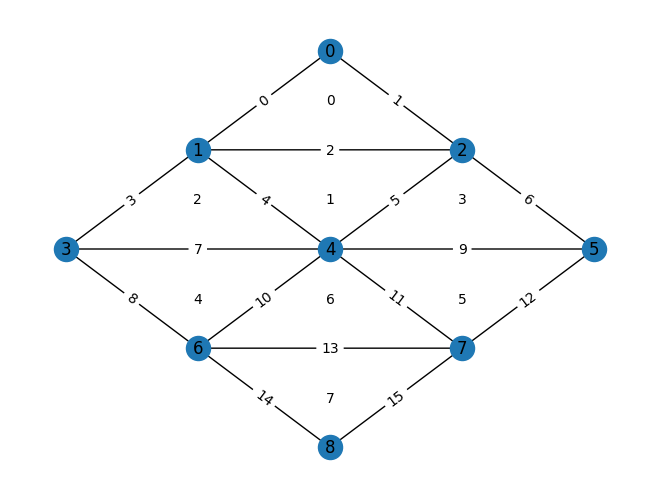

In [2]:
# config = '''
#   *
#  * *
# * * *|
#  * *
# * * *
#  * *
# * * *
#  * *
#   *
# '''
config = '''
  *
 * *
* * *
 * *
  *
'''

lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [3]:
plaquette_energy = 1.
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
#base_link_state[::-1][[1, 5, 11, 16, 22, 27, 33, 37]] = 1
base_link_state[::-1][[1, 5, 11, 15]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

In [4]:
nplaq = dual_lattice.num_plaquettes
hvec = make_hvec(hamiltonian)

@jax.jit
def compute(xmat):
    # pylint: disable-next=unbalanced-tuple-unpacking
    vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)
    return -vals[0], vecs[:, 0]

xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
xmat[0, 0] = 1.
eigval_exact, eigvec_exact = compute(xmat)

INFO:2025-12-12 16:12:17,194:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [5]:
eigval_exact

Array(-11.68876352, dtype=float64)

In [6]:
probs = np.square(np.abs(eigvec_exact))
sort_idx = np.argsort(probs)[::-1]
probs_sorted = probs[sort_idx]

In [7]:
probs_sorted[:20]

array([0.08514561, 0.08514561, 0.08008831, 0.08008831, 0.03156641,
       0.03156641, 0.03156641, 0.03156641, 0.03103279, 0.03103279,
       0.03103279, 0.03103279, 0.02051533, 0.02051533, 0.01700463,
       0.01700463, 0.01700463, 0.01700463, 0.01271375, 0.01271375])

In [8]:
tpoints = np.linspace(0., 3.2, 161)
psi_t = integrate(hvec, nplaq, tpoints)

In [9]:
probs_t = np.square(np.abs(psi_t))

In [10]:
sort_idx_t = np.argsort(probs_t, axis=1)[:, ::-1]

In [11]:
probs_t_sorted = probs_t[np.arange(tpoints.shape[0])[:, None], sort_idx_t]

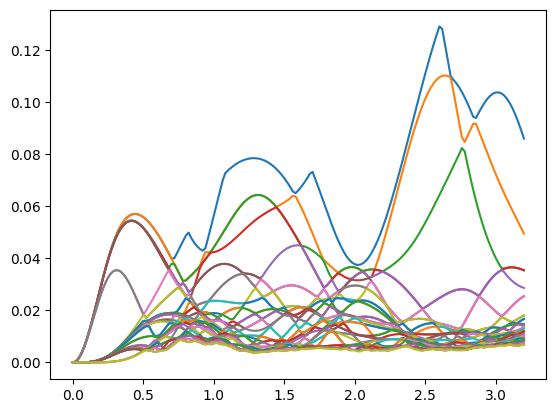

In [12]:
plt.plot(tpoints, probs_t_sorted[:, 1:40]);

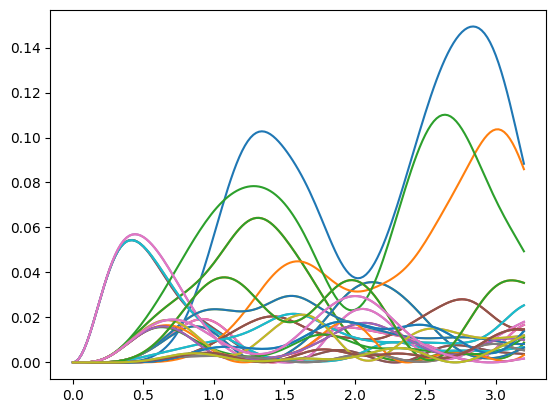

In [13]:
plt.plot(tpoints, probs_t[:, sort_idx[1:40]]);

In [17]:
for idx, prob in zip(sort_idx_t[1, :20], probs_t_sorted[1, :20]):
    print(np.nonzero((idx >> np.arange(nplaq)) % 2)[0], prob)

[] 0.9968061778035566
[5] 0.00039877569875967596
[3] 0.00039877569875967596
[7] 0.00039877560522188257
[0] 0.0003987756052218822
[6] 0.0003987755882198163
[1] 0.0003987755882198163
[4] 0.00039835005171829437
[2] 0.00039835005171829437
[3 5] 1.5955994831104466e-07
[0 1] 1.595598804762336e-07
[6 7] 1.595598804762335e-07
[3 7] 1.595315361563901e-07
[0 5] 1.5953153615639006e-07
[5 7] 1.5953151797828523e-07
[0 3] 1.5953151797828515e-07
[1 5] 1.5953151116635404e-07
[3 6] 1.59531511166354e-07
[0 7] 1.59531498799387e-07
[0 6] 1.5953149198746215e-07


In [18]:
delta_ts = np.linspace(0.1, 1.0, 10)
psi_1 = np.empty((delta_ts.shape[0], 2 ** nplaq), dtype=np.complex128)
psi_2 = np.empty((delta_ts.shape[0], 2 ** nplaq), dtype=np.complex128)
for idt, delta_t in enumerate(delta_ts):
    trotter_uvec = make_trotter_uvec(hamiltonian, delta_t)
    psis = simulate(trotter_uvec, nplaq, 2, num_substeps=1, dims=(1, 2))
    psi_1[idt] = psis[0]
    psi_2[idt] = psis[1]
probs_1 = np.square(np.abs(psi_1))
probs_2 = np.square(np.abs(psi_2))

In [21]:
sort_idx_1 = np.argsort(probs_1, axis=1)[:, ::-1]
sorted_probs_1 = np.sort(probs_1, axis=1)[:, ::-1]

for idx, prob in zip(sort_idx_1[0, :40], sorted_probs_1[0]):
    print(np.nonzero((idx >> np.arange(nplaq)) % 2)[0], prob)

[] 0.92299294323742
[1] 0.009291812807206304
[2] 0.009291812807206302
[0] 0.009291812807206298
[3] 0.009291812807206295
[7] 0.009291812807206293
[6] 0.009291812807206293
[5] 0.009291812807206293
[4] 0.009291812807206293
[2 3] 9.354111087927838e-05
[0 2] 9.354111087927838e-05
[2 5] 9.354111087927838e-05
[1 3] 9.354111087927838e-05
[2 4] 9.354111087927834e-05
[2 6] 9.354111087927831e-05
[2 7] 9.354111087927831e-05
[1 4] 9.354111087927831e-05
[3 6] 9.354111087927828e-05
[4 7] 9.354111087927828e-05
[3 7] 9.354111087927828e-05
[1 7] 9.354111087927828e-05
[3 4] 9.354111087927828e-05
[1 5] 9.354111087927828e-05
[1 2] 9.354111087927828e-05
[1 6] 9.354111087927828e-05
[0 1] 9.354111087927828e-05
[0 6] 9.354111087927824e-05
[0 4] 9.354111087927824e-05
[4 6] 9.354111087927824e-05
[6 7] 9.354111087927824e-05
[0 7] 9.354111087927824e-05
[4 5] 9.354111087927824e-05
[3 5] 9.354111087927824e-05
[0 5] 9.354111087927824e-05
[0 3] 9.354111087927824e-05
[5 7] 9.354111087927822e-05
[5 6] 9.354111087927818e

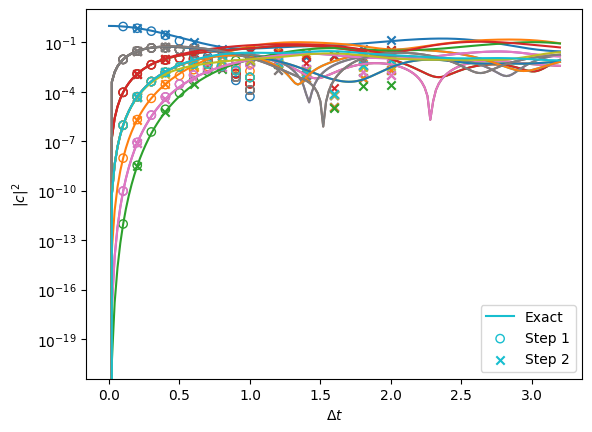

In [ ]:
lines = plt.plot(tpoints, probs_t[:, sort_idx[:20]]);
for idx, line in zip(sort_idx[:20], lines):
    pc1 = plt.scatter(delta_ts, probs_1[:, idx], facecolor='none', edgecolor=line.get_color())
    pc2 = plt.scatter(2. * delta_ts, probs_2[:, idx], marker='x', facecolor=line.get_color())
plt.yscale('log')
plt.xlabel(r'$\Delta t$')
plt.ylabel(r'$|c|^2$')
plt.legend([lines[-1], pc1, pc2], ['Exact', 'Step 1', 'Step 2'])

## H-stack lattice

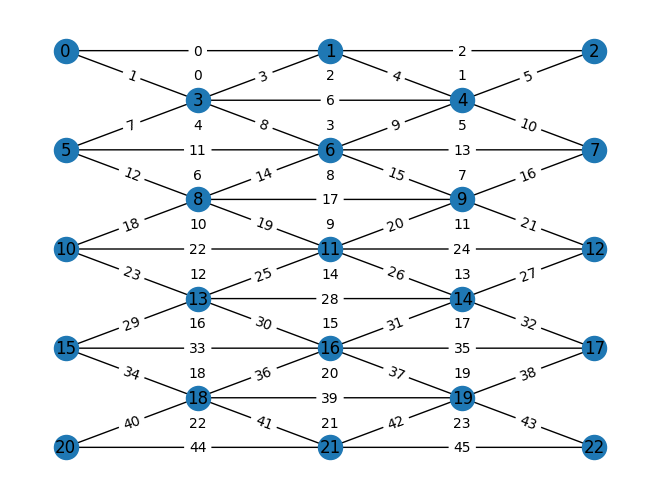

In [2]:
config = '''
* * *
 * *
* * *
 * *
* * *
 * *
* * *
 * *
* * *
'''

lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [ ]:
plaquette_energy = 1.
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][[22, 24]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

In [ ]:
nplaq = dual_lattice.num_plaquettes
hvec = make_hvec(hamiltonian)

@jax.jit
def compute(xmat):
    # pylint: disable-next=unbalanced-tuple-unpacking
    vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)
    return -vals[0], vecs[:, 0]

xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
xmat[0, 0] = 1.
eigval_exact, eigvec_exact = compute(xmat)

INFO:2025-12-10 10:08:59,317:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
